Load Data & feature

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# LOAD FILE
# =========================

df = pd.read_excel('/content/rideBookings_preprocessed1.xlsx')

# Change column names accordingly
df['Date'] = pd.to_datetime(df['Date'])

# Daily demand
daily = df.groupby('Date').size().reset_index(name='demand')

daily.set_index('Date', inplace=True)

# =========================
# FEATURE ENGINEERING
# =========================

data = daily.copy()

data['dayofweek'] = data.index.dayofweek
data['month'] = data.index.month
data['week'] = data.index.isocalendar().week.astype(int)

data['lag_1'] = data['demand'].shift(1)
data['lag_7'] = data['demand'].shift(7)
data['rolling_mean_7'] = data['demand'].rolling(7).mean()

data.dropna(inplace=True)

FEATURES = [
    'dayofweek',
    'month',
    'week',
    'lag_1',
    'lag_7',
    'rolling_mean_7'
]

TARGET = 'demand'

X = data[FEATURES]
y = data[TARGET]

# Time-series split
split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

FORECAST_DAYS = 90

Random Forest Regressor

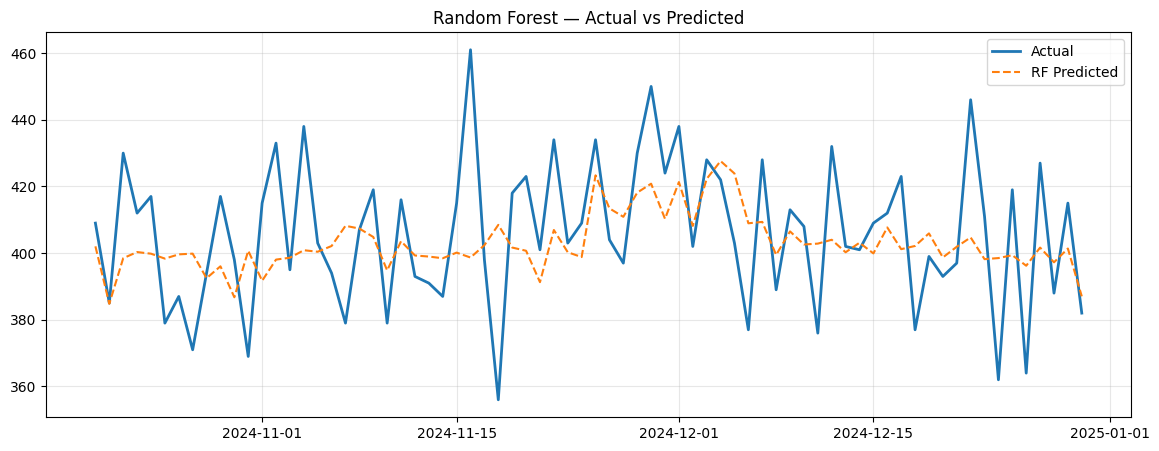

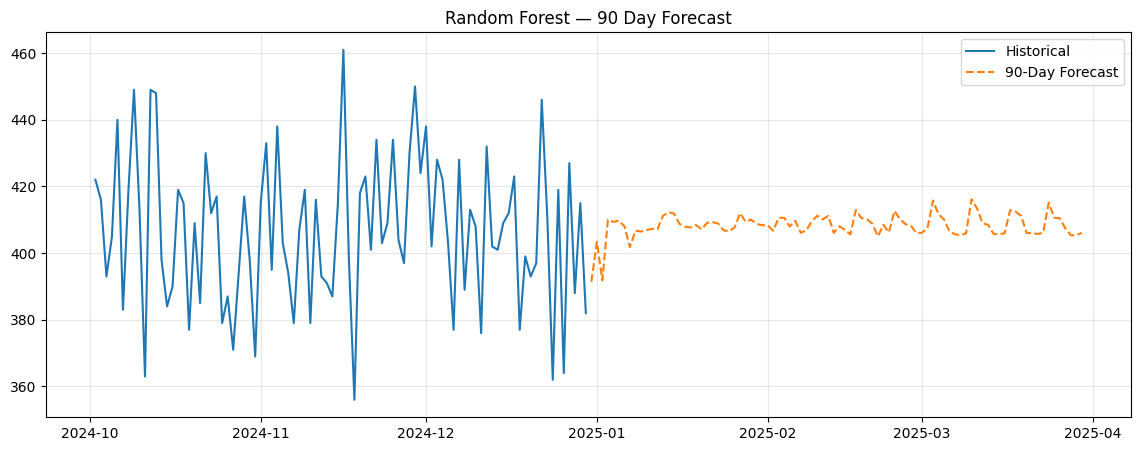

In [ ]:
# =========================
# RANDOM FOREST
# =========================

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# Metrics
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = np.mean(np.abs((y_test-rf_pred)/y_test))*100
rf_r2   = r2_score(y_test, rf_pred)

# Plot Actual vs Predicted
plt.figure(figsize=(14,5))

plt.plot(y_test.index, y_test.values,
         label='Actual', linewidth=2)

plt.plot(y_test.index, rf_pred,
         '--', label='RF Predicted')

plt.title('Random Forest — Actual vs Predicted')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# =========================
# FUTURE FORECAST
# =========================

future_preds_rf = []

temp = data.copy()

for i in range(FORECAST_DAYS):

    next_date = temp.index[-1] + pd.Timedelta(days=1)

    row = {
        'dayofweek': next_date.dayofweek,
        'month': next_date.month,
        'week': int(next_date.isocalendar().week),
        'lag_1': temp['demand'].iloc[-1],
        'lag_7': temp['demand'].iloc[-7],
        'rolling_mean_7': temp['demand'].iloc[-7:].mean()
    }

    row_df = pd.DataFrame([row])

    pred = rf.predict(row_df)[0]

    future_preds_rf.append(pred)

    temp.loc[next_date, 'demand'] = pred

future_dates = pd.date_range(
    start=data.index[-1] + pd.Timedelta(days=1),
    periods=FORECAST_DAYS
)

plt.figure(figsize=(14,5))

plt.plot(data.index[-90:], data['demand'].iloc[-90:],
         label='Historical')

plt.plot(future_dates, future_preds_rf,
         '--', label='90-Day Forecast')

plt.title('Random Forest — 90 Day Forecast')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Gradient Boosting Regressor

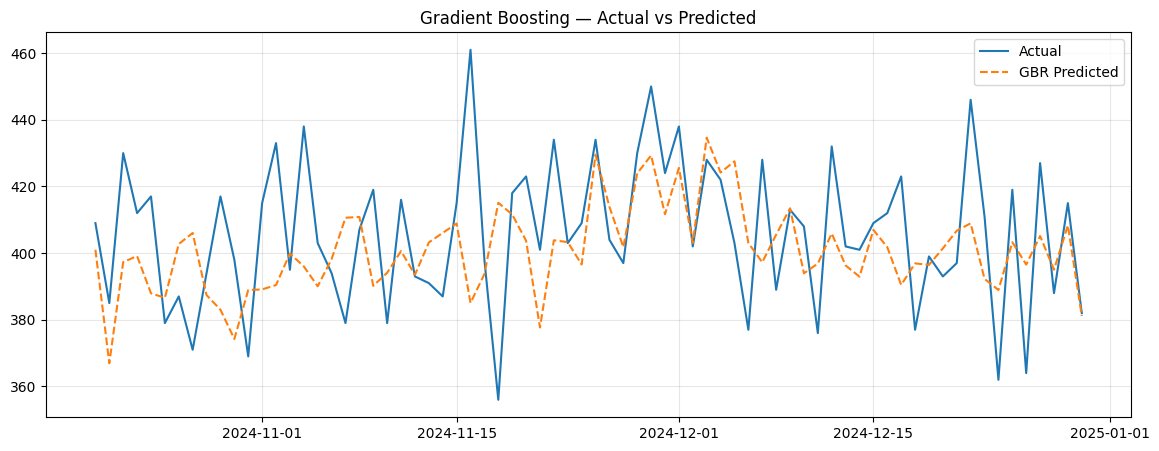

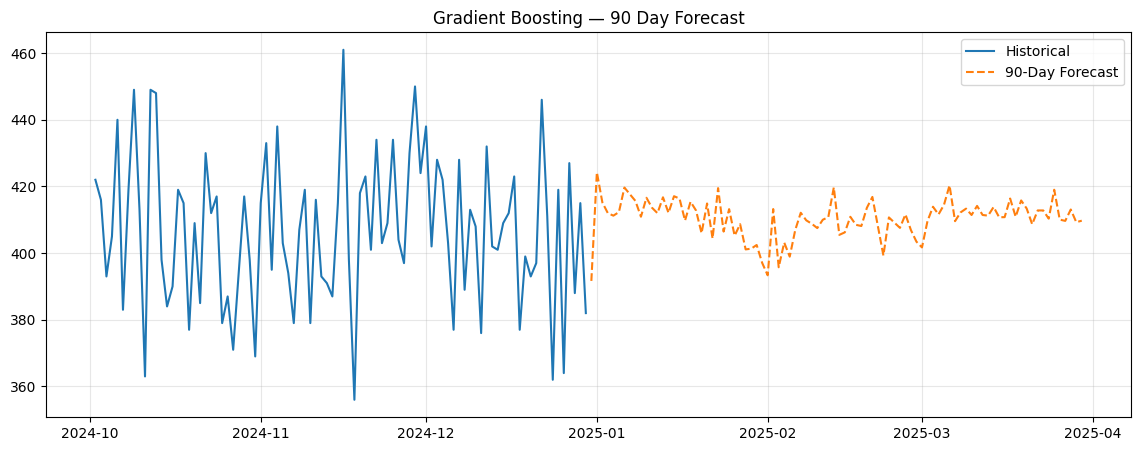

In [ ]:
# =========================
# GRADIENT BOOSTING
# =========================

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)

gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)

# Metrics
gbr_mae  = mean_absolute_error(y_test, gbr_pred)
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))
gbr_mape = np.mean(np.abs((y_test-gbr_pred)/y_test))*100
gbr_r2   = r2_score(y_test, gbr_pred)

# Plot
plt.figure(figsize=(14,5))

plt.plot(y_test.index, y_test.values,
         label='Actual')

plt.plot(y_test.index, gbr_pred,
         '--', label='GBR Predicted')

plt.title('Gradient Boosting — Actual vs Predicted')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Future Forecast
future_preds_gbr = []

temp = data.copy()

for i in range(FORECAST_DAYS):

    next_date = temp.index[-1] + pd.Timedelta(days=1)

    row = {
        'dayofweek': next_date.dayofweek,
        'month': next_date.month,
        'week': int(next_date.isocalendar().week),
        'lag_1': temp['demand'].iloc[-1],
        'lag_7': temp['demand'].iloc[-7],
        'rolling_mean_7': temp['demand'].iloc[-7:].mean()
    }

    row_df = pd.DataFrame([row])

    pred = gbr.predict(row_df)[0]

    future_preds_gbr.append(pred)

    temp.loc[next_date, 'demand'] = pred

plt.figure(figsize=(14,5))

plt.plot(data.index[-90:], data['demand'].iloc[-90:],
         label='Historical')

plt.plot(future_dates, future_preds_gbr,
         '--', label='90-Day Forecast')

plt.title('Gradient Boosting — 90 Day Forecast')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

XGBoost Regressor

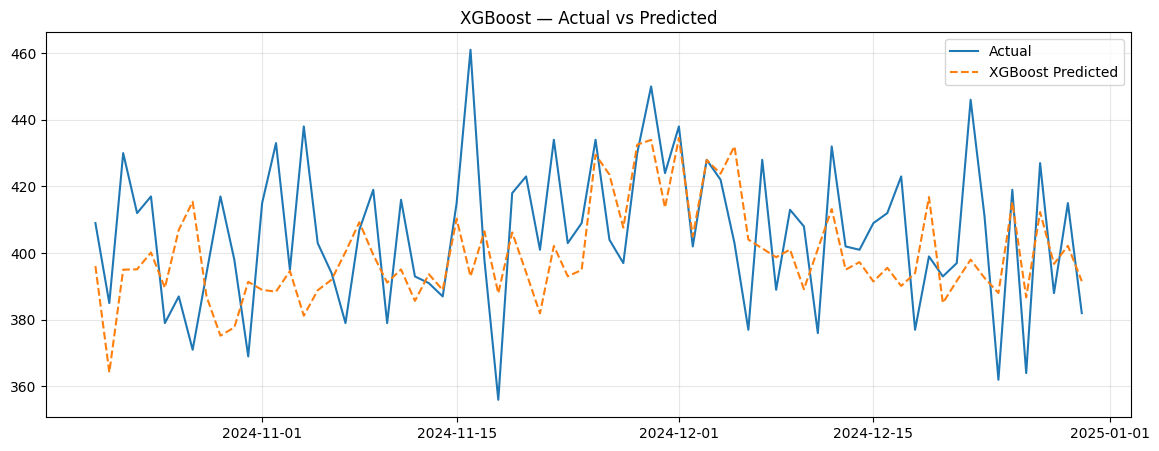

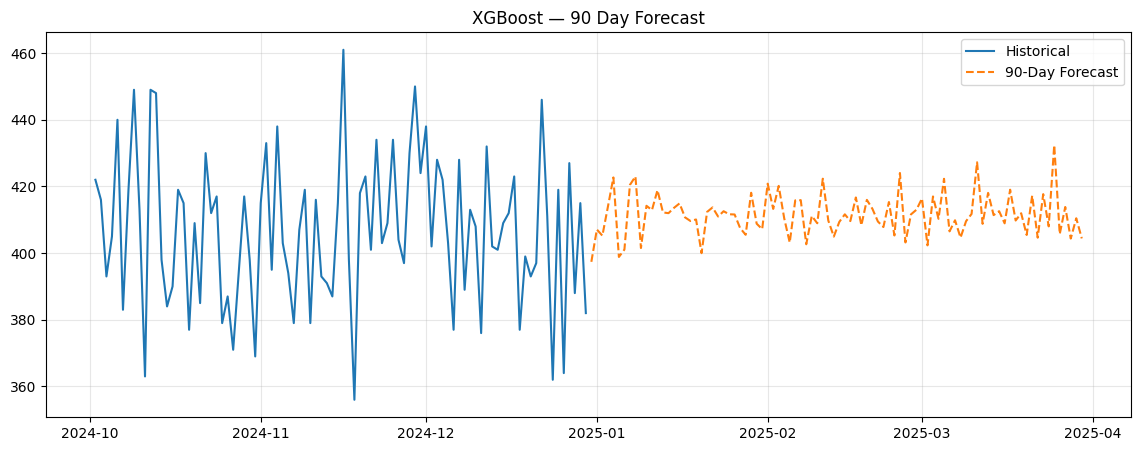

In [ ]:
# =========================
# XGBOOST
# =========================

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

# Metrics
xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = np.mean(np.abs((y_test-xgb_pred)/y_test))*100
xgb_r2   = r2_score(y_test, xgb_pred)

# Plot
plt.figure(figsize=(14,5))

plt.plot(y_test.index, y_test.values,
         label='Actual')

plt.plot(y_test.index, xgb_pred,
         '--', label='XGBoost Predicted')

plt.title('XGBoost — Actual vs Predicted')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Future Forecast
future_preds_xgb = []

temp = data.copy()

for i in range(FORECAST_DAYS):

    next_date = temp.index[-1] + pd.Timedelta(days=1)

    row = {
        'dayofweek': next_date.dayofweek,
        'month': next_date.month,
        'week': int(next_date.isocalendar().week),
        'lag_1': temp['demand'].iloc[-1],
        'lag_7': temp['demand'].iloc[-7],
        'rolling_mean_7': temp['demand'].iloc[-7:].mean()
    }

    row_df = pd.DataFrame([row])

    pred = xgb.predict(row_df)[0]

    future_preds_xgb.append(pred)

    temp.loc[next_date, 'demand'] = pred

plt.figure(figsize=(14,5))

plt.plot(data.index[-90:], data['demand'].iloc[-90:],
         label='Historical')

plt.plot(future_dates, future_preds_xgb,
         '--', label='90-Day Forecast')

plt.title('XGBoost — 90 Day Forecast')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Compare All Models & Best Model


=== Model Comparison ===
                      MAE    RMSE  MAPE(%)
Random Forest      16.286  20.496    4.015
Gradient Boosting  17.306  22.272    4.257
XGBoost            17.485  22.088    4.289

Best Forecasting Model: Random Forest


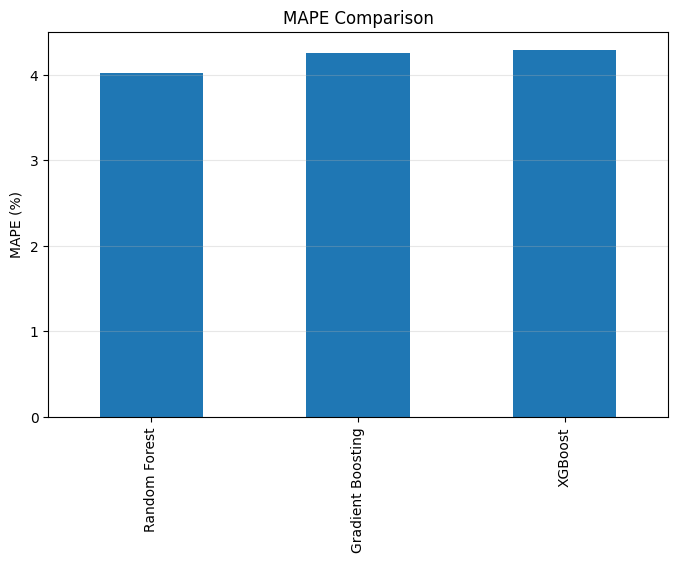

In [ ]:
# =========================
# MODEL COMPARISON
# =========================

comparison = pd.DataFrame({
    'MAE': [
        rf_mae,
        gbr_mae,
        xgb_mae
    ],
    'RMSE': [
        rf_rmse,
        gbr_rmse,
        xgb_rmse
    ],
    'MAPE(%)': [
        rf_mape,
        gbr_mape,
        xgb_mape
    ],

},
index=[
    'Random Forest',
    'Gradient Boosting',
    'XGBoost'
])

comparison = comparison.round(3)

print("\n=== Model Comparison ===")
print(comparison)

# Best model based on lowest MAPE
best_model = comparison['MAPE(%)'].idxmin()

print(f"\nBest Forecasting Model: {best_model}")

# =========================
# BAR PLOT
# =========================

comparison['MAPE(%)'].plot(
    kind='bar',
    figsize=(8,5),
    title='MAPE Comparison'
)

plt.ylabel('MAPE (%)')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
import pickle

# =========================
# SAVE MODELS
# =========================

with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('gradient_boosting_model.pkl', 'wb') as f:
    pickle.dump(gbr, f)

with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

print("Models saved successfully ✓")

# =========================
# SAVE FEATURE LIST
# =========================

with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)

print("Feature columns saved ✓")

# =========================
# SAVE COMPARISON TABLE
# =========================

with open('model_comparison.pkl', 'wb') as f:
    pickle.dump(comparison, f)

print("Comparison metrics saved ✓")

Models saved successfully ✓
Feature columns saved ✓
Comparison metrics saved ✓
